# 04b · Soybean Yield Model

입력: `data/raw/yielddata.csv` (타깃 `soybean`) + `gddMarAug` · `pptMarAug` · `soil*` · `gridInfo`
피처: **04(옥수수)와 완전히 동일** — 온도 노출 분포(전략 A/B), `ppt`, `ppt_sq`, soil 8개, `year`

산출: `data/processed/soybean_panel.parquet` · `soybean_model_final.joblib` · `oof_predictions_soybean.parquet`
· `outputs/results/*_soybean.csv` · `outputs/figures/fig23~26`

---

### 04에서 확정된 제약 (이 노트북도 그대로 지킨다)
1. **평가 분할 = `GroupKFold(stco)`**. 무작위 분할 금지 (카운티 고정효과 누수로 R²가 부풀려짐).
2. **`slope` 제외** (`slope`, `slope_missing` 미사용).
3. **표준화는 파이프라인 안에서만** (`make_pipeline(StandardScaler(), 모델)`), 선형 모델에만.
4. **`GDD_above` 계수를 "고온이 이롭다"로 읽지 않는다** (reference = ≤0℃ 냉량 구간). 해석은 **대체효과 `b_above − b_below`** 로.
5. **타깃 누출성 피처 금지** (카운티별 과거 평균 수확량 류 없음).

### 이 노트북이 04와 다른 유일한 지점
- 타깃이 `corn` → **`soybean`**.
- 따라서 **행 집합이 다르다**: 대두를 재배하지 않는 카운티·연도(`soybean` NA)를 제거한다.
  옥수수 패널(70,721행 / 2,644 카운티)과 **대두 패널은 같지 않다**. 대두 기준으로 패널을 다시 만든다.
- 피처는 카운티×연도 날씨·토양이므로 **옥수수와 공유**한다 (같은 정의, 같은 컬럼).

### 이 노트북이 답해야 할 질문
- 대두 수확량은 옥수수만큼 예측 가능한가? (R² / RMSE 비교)
- **준원님 발견 검증**: "옥수수가 대두보다 고온에 민감하다" — 대두의 고온 감소가 실제로 더 완만한가?
  수확량 수준이 다르므로(옥수수 ~109 vs 대두 ~34 bu/ac) **반드시 상대(%) 기준으로 비교**한다.

In [1]:
import json, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import partial_dependence

RAW = Path('..') / 'data' / 'raw'          # 읽기 전용 (수정 금지)
PROC = Path('..') / 'data' / 'processed'
FIG = Path('..') / 'outputs' / 'figures'
RES = Path('..') / 'outputs' / 'results'
FIG.mkdir(parents=True, exist_ok=True)
RES.mkdir(parents=True, exist_ok=True)

SURFACE, INK, SECOND, MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#898781'
GRID, AXIS = '#e1e0d9', '#c3c2b7'
BLUE, AQUA, YELLOW, GREEN, VIOLET, RED = '#2a78d6', '#1baf7a', '#eda100', '#008300', '#4a3aa7', '#e34948'

mpl.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': SECOND, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Malgun Gothic', 'Segoe UI', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'axes.titlesize': 12.5, 'axes.titleweight': 'semibold',
    'axes.labelsize': 10.5, 'lines.linewidth': 2,
})

def save(fig, name):
    p = FIG / name
    fig.savefig(p, bbox_inches='tight')
    print('saved:', p)

MISSING = []
try:
    import xgboost as xgb
    print('xgboost', xgb.__version__)
except Exception as e:
    xgb = None; MISSING.append('XGBoost (%s)' % type(e).__name__)
try:
    import lightgbm as lgb
    print('lightgbm', lgb.__version__)
except Exception as e:
    lgb = None; MISSING.append('LightGBM (%s)' % type(e).__name__)
try:
    from catboost import CatBoostRegressor
    import catboost
    print('catboost', catboost.__version__)
except Exception as e:
    CatBoostRegressor = None; MISSING.append('CatBoost (%s)' % type(e).__name__)
print('사용 불가 모델:', MISSING if MISSING else '없음')

xgboost 3.1.3
lightgbm 4.6.0
catboost 1.2.10
사용 불가 모델: 없음


## 1. 대두 패널 구성

01(전처리) + 03(피처)의 규칙을 **글자 그대로** 재사용하되, `corn` NA 제거를 **`soybean` NA 제거**로 바꾼다.

| 단계 | 규칙 (04/03과 동일) |
|---|---|
| era 매핑 | 1981–95→1992, 96–03→2001, 04–08→2006, 09–15→2011 (soil·gridInfo 공통) |
| `gddm4` 결측 | **184 − 나머지 120개 합**으로 복원 |
| soil 소수 결측 | 중앙값 (`silt`는 100 − sand − clay 로 복원해 텍스처 제약 보존) |
| `slope` | **사용 안 함** (제약 2) |
| 전략 A | `GDD_below_T` / `GDD_above_T` (T=28~31), reference = ≤0℃ 냉량 구간 |
| 전략 B | 03이 고른 **동일한 86개 구간** (reference `gddp24` drop) |
| 타깃 | **`soybean`** (bu/ac) — NA 행 제거 |

In [2]:
ERA_BINS = [(1981, 1995, 1992), (1996, 2003, 2001), (2004, 2008, 2006), (2009, 2015, 2011)]
def year_to_era(y):
    for lo, hi, era in ERA_BINS:
        if lo <= y <= hi:
            return era
    return np.nan

SOIL_ALL = ['whc', 'sand', 'silt', 'clay', 'om', 'kwfactor', 'kffactor', 'spH', 'slope', 'tfactor']
DAYS = 184.0

yld = pd.read_csv(RAW / 'yielddata.csv')
print('yielddata:', yld.shape, '| corn NA %d | soybean NA %d' % (yld.corn.isna().sum(), yld.soybean.isna().sum()))

base = yld[['stco', 'year', 'corn', 'soybean']].copy()
base['era'] = base['year'].apply(year_to_era)

gdd = pd.read_csv(RAW / 'gddMarAug.csv').dropna(subset=['year'])
gdd['year'] = gdd['year'].astype(int)
GDD = [c for c in gdd.columns if c not in ('stco', 'year')]

ppt = pd.read_csv(RAW / 'pptMarAug.csv').dropna(subset=['year'])
ppt['year'] = ppt['year'].astype(int)

soil_all = pd.concat([pd.read_csv(RAW / ('soil%d.csv' % era)).assign(era=era)
                      for era in (1992, 2001, 2006, 2011)], ignore_index=True)

grid = pd.read_csv(RAW / 'gridInfo.csv')
num_cols = ['numAg1992', 'numAg2001', 'numAg2006', 'numAg2011']
ac = (grid.groupby('stco', as_index=False)[num_cols].sum()
          .melt(id_vars='stco', value_vars=num_cols, var_name='numcol', value_name='A_c'))
ac['era'] = ac['numcol'].str.replace('numAg', '').astype(int)
ac = ac.drop(columns='numcol')

panel = (base.merge(gdd, on=['stco', 'year'], how='left')
              .merge(ppt, on=['stco', 'year'], how='left')
              .merge(soil_all, on=['stco', 'era'], how='left')
              .merge(ac, on=['stco', 'era'], how='left'))
print('머지 후:', panel.shape)

# --- 타깃 필터: soybean NA 제거 (04는 corn NA 제거) ---
n0 = len(panel)
df = panel.dropna(subset=['soybean']).reset_index(drop=True)
print('soybean NA 제거: %d -> %d 행 (제거 %d)' % (n0, len(df), n0 - len(df)))

corn_counties = set(panel.dropna(subset=['corn']).stco.unique())
soy_counties = set(df.stco.unique())
print()
print('옥수수 패널 : %d행 / %d 카운티' % (panel.corn.notna().sum(), len(corn_counties)))
print('대두   패널 : %d행 / %d 카운티' % (len(df), len(soy_counties)))
print('  둘 다 재배 : %d 카운티' % len(corn_counties & soy_counties))
print('  옥수수만   : %d 카운티' % len(corn_counties - soy_counties))
print('  대두만     : %d 카운티  <- 옥수수 패널에 없던 카운티' % len(soy_counties - corn_counties))
assert df[GDD + ['ppt'] + ['A_c']].isna().sum().sum() == df['gddm4'].isna().sum(), 'gddm4 외 날씨/면적 결측이 있다'

yielddata: (107450, 6) | corn NA 36729 | soybean NA 50490
머지 후: (107450, 138)
soybean NA 제거: 107450 -> 56960 행 (제거 50490)

옥수수 패널 : 70721행 / 2644 카운티
대두   패널 : 56960행 / 2169 카운티
  둘 다 재배 : 2142 카운티
  옥수수만   : 502 카운티
  대두만     : 27 카운티  <- 옥수수 패널에 없던 카운티


In [3]:
# --- 03과 동일한 결측 처리 ---
na_g = df['gddm4'].isna()
others = [c for c in GDD if c != 'gddm4']
if na_g.any():
    recon = DAYS - df.loc[na_g, others].sum(axis=1)
    print('gddm4 결측 %d행 -> 184 - 나머지합 = %s 로 복원' % (na_g.sum(), np.round(recon.values, 4)))
    df.loc[na_g, 'gddm4'] = recon

SOIL_MEDIAN = ['whc', 'sand', 'clay', 'om', 'kwfactor', 'kffactor', 'spH', 'tfactor']
n_med = int(df[SOIL_MEDIAN].isna().sum().sum())
df[SOIL_MEDIAN] = df[SOIL_MEDIAN].fillna(df[SOIL_MEDIAN].median())
n_silt = int(df['silt'].isna().sum())
df['silt'] = df['silt'].fillna(100.0 - df['sand'] - df['clay'])
print('soil 대체: 중앙값 %d셀 + silt %d셀(=100-sand-clay)' % (n_med, n_silt))
print('slope 결측 %d행 -> 제약 2에 따라 slope 자체를 쓰지 않으므로 대체하지 않는다' % int(df['slope'].isna().sum()))

tex = df[['sand', 'silt', 'clay']].sum(axis=1)
assert np.allclose(tex, 100.0), '텍스처 제약(sand+silt+clay=100) 위반'
assert df[GDD + SOIL_MEDIAN + ['silt', 'ppt']].isna().sum().sum() == 0
print('\n결측 처리 후 남은 결측: 0')

# --- 184 제약 확인 ---
row_sum = df[GDD].sum(axis=1)
bad = int((np.abs(row_sum - DAYS) > 0.1).sum())
print('gdd 121구간 행별 합: mean %.4f std %.5f min %.3f | |합-184|>0.1 인 행 %d개 (%.2f%%, 원자료 결손 — 04 옥수수 패널과 동일 성격)'
      % (row_sum.mean(), row_sum.std(), row_sum.min(), bad, 100 * bad / len(df)))

gddm4 결측 1행 -> 184 - 나머지합 = [2.3104] 로 복원
soil 대체: 중앙값 24셀 + silt 3셀(=100-sand-clay)
slope 결측 1335행 -> 제약 2에 따라 slope 자체를 쓰지 않으므로 대체하지 않는다

결측 처리 후 남은 결측: 0
gdd 121구간 행별 합: mean 183.9996 std 0.01127 min 182.987 | |합-184|>0.1 인 행 63개 (0.11%, 원자료 결손 — 04 옥수수 패널과 동일 성격)


In [4]:
# --- 03과 동일한 피처 생성 ---
spec = json.load(open(PROC / 'feature_columns.json', encoding='utf-8'))
SOIL = spec['strategy_A']['soil']                 # silt 제외된 8개
CANON = spec['strategy_A']['canonical_threshold'] # 29
THRESHOLDS = spec['strategy_A']['thresholds_available']
GDD_BINS = spec['strategy_B']['gdd_bins']         # 86개 (gddp24 = reference, 이미 제외)
REF_BIN = spec['strategy_B']['reference_bin_dropped']

def temp_of(c):
    if c == 'gdd0':
        return 0
    return int(c[4:]) if c.startswith('gddp') else -int(c[4:])

TEMPS = np.array([temp_of(c) for c in GDD])

df['ppt_sq'] = df['ppt'] ** 2
df['soy_dm'] = df['soybean'] - df.groupby('year')['soybean'].transform('mean')   # 연도평균 제거 (해석용)

for t in THRESHOLDS:
    bel = [c for c in GDD if c.startswith('gddp') and 1 <= temp_of(c) <= t]
    abv = [c for c in GDD if c.startswith('gddp') and temp_of(c) > t]
    df['GDD_below_%d' % t] = df[bel].sum(axis=1)
    df['GDD_above_%d' % t] = df[abv].sum(axis=1)
df['GDD_cold'] = df[[c for c in GDD if temp_of(c) <= 0]].sum(axis=1)   # reference (모델 투입 금지)

chk = df['GDD_below_29'] + df['GDD_above_29'] + df['GDD_cold']
print('below29 + above29 + cold = %.3f (std %.4f) -> 184 복원 확인' % (chk.mean(), chk.std()))

# 03이 고른 86개 구간이 대두 패널에서도 유효한지 (제외된 구간에 노출이 새로 생기지 않았는지)
excluded = [c for c in GDD if c not in GDD_BINS and c != REF_BIN]
extra = df[excluded].sum()
extra = extra[extra > 0]
print('전략 B 구간: 03의 %d개 그대로 사용 (reference=%s, %d℃)' % (len(GDD_BINS), REF_BIN, temp_of(REF_BIN)))
print('  03이 제외한 구간 중 대두 패널에서 노출이 생긴 구간: %s' % (extra.to_dict() if len(extra) else '없음 -> 피처공간 동일'))

# --- 저장 ---
KEYS = ['stco', 'year']
TARGETS = ['soybean', 'soy_dm']
CARRY = ['A_c', 'corn', 'silt', 'GDD_cold']       # 모델 피처 아님 (corn은 참조용, A_c는 06 가중치)
gdd_pairs = [('GDD_%s_%d' % (s, t)) for t in THRESHOLDS for s in ('below', 'above')]
out_cols = KEYS + TARGETS + CARRY + gdd_pairs + GDD_BINS + ['ppt', 'ppt_sq'] + SOIL
soy_panel = df[out_cols].copy()
soy_panel.to_parquet(PROC / 'soybean_panel.parquet', index=False)
print('\n저장: %s  %s' % (PROC / 'soybean_panel.parquet', soy_panel.shape))
print('대두 수확량: mean %.1f  std %.1f  min %.1f  max %.1f (bu/ac)'
      % (df.soybean.mean(), df.soybean.std(), df.soybean.min(), df.soybean.max()))

below29 + above29 + cold = 184.000 (std 0.0113) -> 184 복원 확인
전략 B 구간: 03의 86개 그대로 사용 (reference=gddp24, 24℃)
  03이 제외한 구간 중 대두 패널에서 노출이 생긴 구간: 없음 -> 피처공간 동일

저장: ../data/processed/soybean_panel.parquet  (56960, 112)
대두 수확량: mean 33.7  std 10.5  min 0.7  max 73.1 (bu/ac)


### 1-1. 피처셋 · 제약 검증

04와 **완전히 같은 피처 리스트**를 쓴다 (`feature_columns.json`에서 그대로 읽음).
- **전략 A** (13개): `year` + `GDD_below_29` + `GDD_above_29` + `ppt` + `ppt_sq` + soil 8
- **전략 B** (97개): `year` + 온도구간 86 + `ppt` + `ppt_sq` + soil 8

아래에서 04가 저장한 `yield_model_final.joblib`의 피처 리스트와 **문자 그대로 일치**하는지 assert 한다.

In [5]:
FEAT_A = ['year', 'GDD_below_%d' % CANON, 'GDD_above_%d' % CANON, 'ppt', 'ppt_sq'] + SOIL
FEAT_B = ['year'] + GDD_BINS + ['ppt', 'ppt_sq'] + SOIL

BANNED = {'slope', 'slope_missing', 'soybean', 'soy_dm', 'corn', 'corn_dm', 'A_c', 'GDD_cold', 'silt', 'stco'}
for tag, F in [('A', FEAT_A), ('B', FEAT_B)]:
    bad = BANNED & set(F)
    assert not bad, '금지 컬럼이 피처에 있음: %s' % bad
    assert len(F) == len(set(F)), '중복 컬럼'
print('제약 검증 통과: slope 제외 · 타깃(누출) 파생 피처 없음 · 04와 동일한 피처 정의')

# 04(옥수수)가 실제로 쓴 피처 리스트와 문자 그대로 같은지 대조
corn_bundle = joblib.load(PROC / 'yield_model_final.joblib')
print('\n04 옥수수 최종모델: %s (전략 %s), 피처 %d개, CV R² %.4f'
      % (corn_bundle['model_name'], corn_bundle['strategy'], len(corn_bundle['features']), corn_bundle['cv_r2_mean']))
corn_feats = list(corn_bundle['features'])
mine = FEAT_B if corn_bundle['strategy'] == 'B' else FEAT_A
assert corn_feats == mine, '04와 피처 리스트가 다르다:\n  04: %s\n  04b: %s' % (corn_feats[:5], mine[:5])
print('=> 04 옥수수 모델과 피처 리스트 완전 일치 (같은 날씨·토양 공간에서 학습)')

y = soy_panel['soybean'].to_numpy(float)
groups = soy_panel['stco'].to_numpy()
XA, XB = soy_panel[FEAT_A].copy(), soy_panel[FEAT_B].copy()
print('\nFEAT_A %d개 | FEAT_B %d개' % (len(FEAT_A), len(FEAT_B)))
print('타깃 soybean: mean %.1f  std %.1f  n=%d  counties=%d'
      % (y.mean(), y.std(), len(y), soy_panel.stco.nunique()))

제약 검증 통과: slope 제외 · 타깃(누출) 파생 피처 없음 · 04와 동일한 피처 정의

04 옥수수 최종모델: RandomForest (전략 B), 피처 97개, CV R² 0.7362
=> 04 옥수수 모델과 피처 리스트 완전 일치 (같은 날씨·토양 공간에서 학습)

FEAT_A 13개 | FEAT_B 97개
타깃 soybean: mean 33.7  std 10.5  n=56960  counties=2169


## 2. 평가 프로토콜 — `GroupKFold(stco)` 5-fold

04와 **동일**. 같은 카운티가 학습과 테스트에 동시에 등장하지 않는다.
모델 하이퍼파라미터도 04와 동일하게 두어야 옥수수 vs 대두 비교가 공정하다 (튜닝 차이가 섞이면 안 된다).

> `LassoCV`/`ElasticNetCV`의 **내부** alpha 선택 CV는 그룹 인지가 아니다(sklearn 제약).
> 다만 **바깥 평가 분할은 그룹 분할**이므로 보고 수치의 정직성은 유지된다.

In [6]:
N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)

def rmse(a, b):
    return float(np.sqrt(mean_squared_error(a, b)))

def cv_eval(name, factory, X, y, groups):
    oof = np.full(len(y), np.nan)
    r2s, rmses, maes = [], [], []
    t0 = time.time()
    for tr, te in gkf.split(X, y, groups):
        m = factory()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            m.fit(X.iloc[tr], y[tr])
            p = m.predict(X.iloc[te])
        oof[te] = p
        r2s.append(r2_score(y[te], p)); rmses.append(rmse(y[te], p)); maes.append(mean_absolute_error(y[te], p))
    return {'model': name, 'r2_mean': np.mean(r2s), 'r2_std': np.std(r2s),
            'rmse_mean': np.mean(rmses), 'rmse_std': np.std(rmses),
            'mae_mean': np.mean(maes), 'mae_std': np.std(maes),
            'r2_folds': '|'.join('%.3f' % v for v in r2s),
            'seconds': time.time() - t0}, oof

def build_factories():
    f = {
        'OLS':          lambda: make_pipeline(StandardScaler(), LinearRegression()),
        'Ridge':        lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 4, 25))),
        'Lasso':        lambda: make_pipeline(StandardScaler(), LassoCV(cv=3, n_jobs=-1, random_state=0, max_iter=5000)),
        'ElasticNet':   lambda: make_pipeline(StandardScaler(), ElasticNetCV(cv=3, l1_ratio=[.2, .5, .8, .95],
                                                                            n_jobs=-1, random_state=0, max_iter=5000)),
        'RandomForest': lambda: RandomForestRegressor(n_estimators=150, min_samples_leaf=5, n_jobs=-1, random_state=0),
        'GradientBoosting': lambda: GradientBoostingRegressor(n_estimators=150, max_depth=3, subsample=0.7, random_state=0),
    }
    if xgb is not None:
        f['XGBoost'] = lambda: xgb.XGBRegressor(n_estimators=600, max_depth=6, learning_rate=0.05,
                                                subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
                                                random_state=0, tree_method='hist')
    if lgb is not None:
        f['LightGBM'] = lambda: lgb.LGBMRegressor(n_estimators=600, num_leaves=63, learning_rate=0.05,
                                                  subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
                                                  random_state=0, verbose=-1)
    if CatBoostRegressor is not None:
        f['CatBoost'] = lambda: CatBoostRegressor(iterations=800, depth=6, learning_rate=0.05,
                                                  random_seed=0, verbose=0, allow_writing_files=False)
    return f

FACTORIES = build_factories()
print('평가할 모델 %d개 (04와 동일한 하이퍼파라미터): %s' % (len(FACTORIES), list(FACTORIES)))

평가할 모델 9개 (04와 동일한 하이퍼파라미터): ['OLS', 'Ridge', 'Lasso', 'ElasticNet', 'RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost']


In [7]:
results, oofs = [], {}
for strat, X in [('A', XA), ('B', XB)]:
    print('\n===== 전략 %s (%d features) =====' % (strat, X.shape[1]))
    for name, fac in FACTORIES.items():
        row, oof = cv_eval(name, fac, X, y, groups)
        row['strategy'] = strat
        results.append(row); oofs[(name, strat)] = oof
        print('  %-17s R2 %.4f ± %.4f | RMSE %6.2f | MAE %5.2f | %5.1fs'
              % (name, row['r2_mean'], row['r2_std'], row['rmse_mean'], row['mae_mean'], row['seconds']))

res = pd.DataFrame(results)[['model', 'strategy', 'r2_mean', 'r2_std', 'rmse_mean', 'rmse_std',
                             'mae_mean', 'mae_std', 'r2_folds', 'seconds']].sort_values('r2_mean', ascending=False)
res.to_csv(RES / 'model_comparison_soybean.csv', index=False)
print('\n저장: %s' % (RES / 'model_comparison_soybean.csv'))
print()
print(res.drop(columns='r2_folds').round(4).to_string(index=False))

unstable = res[res.r2_std > 0.1]
if len(unstable):
    print('\n[!] fold 간 R2 편차가 큰 모델 (붕괴 의심):')
    for _, r in unstable.iterrows():
        print('   %-8s 전략 %s : fold별 R2 = %s' % (r.model, r.strategy, r.r2_folds))


===== 전략 A (13 features) =====
  OLS               R2 0.5305 ± 0.0116 | RMSE   7.20 | MAE  5.62 |   0.0s
  Ridge             R2 0.5306 ± 0.0116 | RMSE   7.20 | MAE  5.62 |   0.1s
  Lasso             R2 0.5306 ± 0.0116 | RMSE   7.20 | MAE  5.63 |   0.2s
  ElasticNet        R2 0.5304 ± 0.0116 | RMSE   7.21 | MAE  5.63 |   0.3s
  RandomForest      R2 0.7638 ± 0.0099 | RMSE   5.11 | MAE  3.86 |  19.5s
  GradientBoosting  R2 0.6688 ± 0.0101 | RMSE   6.05 | MAE  4.72 |  40.8s
  XGBoost           R2 0.7598 ± 0.0103 | RMSE   5.15 | MAE  3.95 |   4.5s
  LightGBM          R2 0.7720 ± 0.0114 | RMSE   5.02 | MAE  3.83 |  25.2s
  CatBoost          R2 0.7401 ± 0.0104 | RMSE   5.36 | MAE  4.13 |   5.5s

===== 전략 B (97 features) =====
  OLS               R2 0.5697 ± 0.0102 | RMSE   6.90 | MAE  5.37 |   0.4s
  Ridge             R2 0.5698 ± 0.0102 | RMSE   6.90 | MAE  5.37 |   1.1s
  Lasso             R2 0.5695 ± 0.0099 | RMSE   6.90 | MAE  5.37 |   1.0s
  ElasticNet        R2 0.5695 ± 0.0099 | RMSE   

saved: ../outputs/figures/fig23_soy_model_comparison.png


/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38702/960647812.py:44: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38702/960647812.py:44: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38702/960647812.py:44: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38702/960647812.py:44: UserWarning: Glyph 47029 (\N{HANGUL SYLLABLE RYAG}) missing from font(s) DejaVu Sans.
  fig.savefig(p, bbox_inches='tight')
/var/folders/n9/b8tp0fks6817kkqprp040r380000gn/T/ipykernel_38702/960647812.py:44: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.save

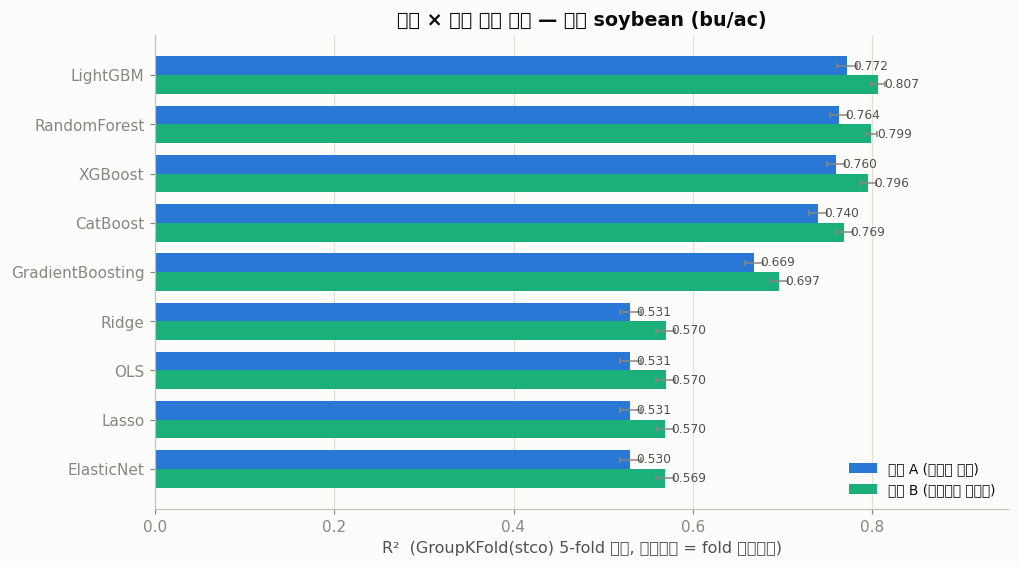

In [8]:
fig, ax = plt.subplots(figsize=(10, 5.6))
piv = res.pivot(index='model', columns='strategy', values='r2_mean')
err = res.pivot(index='model', columns='strategy', values='r2_std')
order = piv.max(axis=1).sort_values().index
piv, err = piv.loc[order], err.loc[order]

ax.set_axisbelow(True); ax.grid(axis='y', visible=False)
ypos = np.arange(len(piv)); h = 0.38
ax.barh(ypos + h/2, piv['A'], height=h, color=BLUE, xerr=err['A'],
        error_kw=dict(ecolor=MUTED, elinewidth=1, capsize=2), label='전략 A (도메인 압축)')
ax.barh(ypos - h/2, piv['B'], height=h, color=AQUA, xerr=err['B'],
        error_kw=dict(ecolor=MUTED, elinewidth=1, capsize=2), label='전략 B (온도구간 원자료)')
for i, m in enumerate(piv.index):
    ax.annotate('%.3f' % piv['A'][m], xy=(piv['A'][m], i + h/2), xytext=(4, 0),
                textcoords='offset points', va='center', fontsize=8, color=SECOND)
    ax.annotate('%.3f' % piv['B'][m], xy=(piv['B'][m], i - h/2), xytext=(4, 0),
                textcoords='offset points', va='center', fontsize=8, color=SECOND)
ax.set_yticks(ypos); ax.set_yticklabels(piv.index)
ax.set_xlim(min(0, piv.min().min() * 1.1), max(piv.max()) * 1.18)
ax.set_xlabel('R²  (GroupKFold(stco) 5-fold 평균, 오차막대 = fold 표준편차)')
ax.set_title('모델 × 전략 성능 비교 — 타깃 soybean (bu/ac)')
ax.legend(frameon=False, fontsize=9, loc='lower right')
save(fig, 'fig23_soy_model_comparison.png'); plt.show()

In [9]:
# 전략 A vs B 는 같은 모델끼리 짝지어 비교 (04와 동일한 논리)
pair = res.pivot(index='model', columns='strategy', values='r2_mean')
pair['B - A'] = pair['B'] - pair['A']
pair = pair.sort_values('B - A', ascending=False)
print('같은 모델 내 전략 B - 전략 A (R2 차이) — 대두')
print(pair.round(4).to_string())

TREE = [m for m in ['RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost'] if m in pair.index]
LIN = [m for m in ['OLS', 'Ridge', 'Lasso', 'ElasticNet'] if m in pair.index]
print()
print('트리/부스팅 %d개 중 B 우세: %d/%d (평균 %+.4f)'
      % (len(TREE), int((pair.loc[TREE, 'B - A'] > 0).sum()), len(TREE), pair.loc[TREE, 'B - A'].mean()))
print('선형 %d개 중 B 우세: %d/%d' % (len(LIN), int((pair.loc[LIN, 'B - A'] > 0).sum()), len(LIN)))
print()
print('모델군별 최고 R²:  선형 %.4f | sklearn 트리 %.4f | 최신 부스팅 %.4f'
      % (res[res.model.isin(LIN)].r2_mean.max(),
         res[res.model.isin(['RandomForest', 'GradientBoosting'])].r2_mean.max(),
         res[res.model.isin(['XGBoost', 'LightGBM', 'CatBoost'])].r2_mean.max()))

best_row = res.iloc[0]
BEST_NAME, BEST_STRAT = best_row['model'], best_row['strategy']
X_best = XA if BEST_STRAT == 'A' else XB
print('\n대두 최고 모델: %s (전략 %s)  R² %.4f ± %.4f | RMSE %.2f | MAE %.2f'
      % (BEST_NAME, BEST_STRAT, best_row['r2_mean'], best_row['r2_std'], best_row['rmse_mean'], best_row['mae_mean']))

같은 모델 내 전략 B - 전략 A (R2 차이) — 대두
strategy               A       B   B - A
model                                   
Ridge             0.5306  0.5698  0.0392
OLS               0.5305  0.5697  0.0392
ElasticNet        0.5304  0.5695  0.0390
Lasso             0.5306  0.5695  0.0390
XGBoost           0.7598  0.7956  0.0358
RandomForest      0.7638  0.7995  0.0357
LightGBM          0.7720  0.8067  0.0347
CatBoost          0.7401  0.7691  0.0291
GradientBoosting  0.6688  0.6968  0.0280

트리/부스팅 5개 중 B 우세: 5/5 (평균 +0.0327)
선형 4개 중 B 우세: 4/4

모델군별 최고 R²:  선형 0.5698 | sklearn 트리 0.7995 | 최신 부스팅 0.8067

대두 최고 모델: LightGBM (전략 B)  R² 0.8067 ± 0.0078 | RMSE 4.62 | MAE 3.51


**해석 — 승자 조합은 옥수수와 똑같다(LightGBM / 전략 B). 다만 대두가 더 잘 맞는다.**

- **부스팅 > 선형**: 선형 최고 0.570 → LightGBM-B **0.807** (+0.24 R²). 옥수수와 같은 패턴이다.
- **전략 B가 9개 모델 *전부* 에서 A보다 우세**(+0.028 ~ +0.039). 86개 1℃ 구간이 압축된 below/above
  두 개보다 정보를 더 담는다는 04의 결론이 대두에서도 재현된다.
- ⚠️ **04와 갈리는 지점 하나 — 대두에서는 OLS/Ridge-B가 붕괴하지 않는다.**
  옥수수에서는 전략 B의 OLS/Ridge가 R² 0.09/0.11, fold 표준편차 0.69로 무너졌다(한 fold R²≈−1.3).
  대두에서는 같은 피처·같은 공선성(인접 구간 상관 0.94)인데도 **R² 0.570, fold 표준편차 0.006** 으로 멀쩡하다.
  → 붕괴의 원인은 공선성 **단독**이 아니라 **공선성 + 강한 비선형 타깃**의 조합이다. 대두의 온도 반응이
  더 완만해서(아래 4·5절) 선형해가 안정적으로 잡힌다. 03/04의 "정규화가 필요하다"는 결론 자체는 유지되지만,
  그 심각성은 **작물마다 다르다**는 점이 새로 드러났다.

### 2-1. `year` 피처의 기여도

`year`는 달력 변수이지 타깃 파생이 아니므로 제약 5(누출)에 해당하지 않는다. 대두에도 기술추세가 있는지 본다.

In [10]:
row_noyear, _ = cv_eval(BEST_NAME + ' (no year)', FACTORIES[BEST_NAME],
                        X_best.drop(columns=['year']), y, groups)
print('year 포함: R² %.4f | RMSE %.2f' % (best_row['r2_mean'], best_row['rmse_mean']))
print('year 제외: R² %.4f | RMSE %.2f' % (row_noyear['r2_mean'], row_noyear['rmse_mean']))
print('year 기여: ΔR² %+.4f' % (best_row['r2_mean'] - row_noyear['r2_mean']))

# 참고: 대두 기술추세 (연도별 전국평균의 선형 기울기)
yr = soy_panel.groupby('year')['soybean'].mean()
sl = np.polyfit(yr.index, yr.values, 1)[0]
print('\n대두 연도별 전국평균 추세: %+.3f bu/ac/년 (04 옥수수 +1.77 bu/ac/년)' % sl)
print('  평균 대비 상대 추세: 대두 %+.2f%%/년' % (100 * sl / soy_panel.soybean.mean()))

year 포함: R² 0.8067 | RMSE 4.62
year 제외: R² 0.7450 | RMSE 5.31
year 기여: ΔR² +0.0617

대두 연도별 전국평균 추세: +0.486 bu/ac/년 (04 옥수수 +1.77 bu/ac/년)
  평균 대비 상대 추세: 대두 +1.44%/년


### 2-2. Lasso / ElasticNet 이 고른 피처

In [11]:
def selected(model_name, X, F):
    pipe = FACTORIES[model_name]()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        pipe.fit(X, y)                      # 전체 데이터 (기술적 요약 목적, 성능평가 아님)
    coef = pd.Series(pipe[-1].coef_, index=F)
    return pipe, coef, coef[coef != 0]

sel_rows = []
for mname in ['Lasso', 'ElasticNet']:
    for strat, X, F in [('A', XA, FEAT_A), ('B', XB, FEAT_B)]:
        pipe, coef, nz = selected(mname, X, F)
        print('%s / 전략 %s : alpha=%.4f, 살아남은 피처 %d/%d' % (mname, strat, pipe[-1].alpha_, len(nz), len(F)))
        top = nz.reindex(nz.abs().sort_values(ascending=False).index)[:8]
        print('   상위 |coef|:', ', '.join('%s %+.2f' % (k, v) for k, v in top.items()))
        if strat == 'B':
            print('   온도구간 생존 %d/%d개' % (len([c for c in nz.index if c.startswith('gdd')]), len(GDD_BINS)))
        for k, v in coef.items():
            sel_rows.append({'model': mname, 'strategy': strat, 'feature': k, 'coef': v, 'selected': int(v != 0)})
        print()

pd.DataFrame(sel_rows).to_csv(RES / 'lasso_elasticnet_selected_soybean.csv', index=False)
print('저장:', RES / 'lasso_elasticnet_selected_soybean.csv')
print('\n[제약 4] 위 계수에서 GDD_above_29가 양수여도 "고온이 이롭다"가 아니다 (reference = ≤0℃ 냉량일).')
print('         온도의 실제 효과는 아래 5절 고정효과 모델의 대체효과로 판단한다.')

Lasso / 전략 A : alpha=0.0049, 살아남은 피처 12/13
   상위 |coef|: ppt +6.00, sand -5.32, ppt_sq -5.01, GDD_below_29 +4.95, year +4.26, clay -4.17, spH +2.76, kffactor -1.34

Lasso / 전략 B : alpha=0.0158, 살아남은 피처 55/97
   상위 |coef|: sand -4.79, year +4.29, clay -4.08, ppt +3.57, ppt_sq -3.34, spH +3.15, gddp31 -1.34, kwfactor -1.19
   온도구간 생존 44/86개

ElasticNet / 전략 A : alpha=0.0061, 살아남은 피처 13/13
   상위 |coef|: ppt +5.59, sand -5.12, GDD_below_29 +4.90, ppt_sq -4.62, year +4.26, clay -4.04, spH +2.72, kffactor -1.23

ElasticNet / 전략 B : alpha=0.0155, 살아남은 피처 55/97
   상위 |coef|: sand -4.72, year +4.29, clay -4.03, ppt +3.47, ppt_sq -3.24, spH +3.14, gddp31 -1.31, kwfactor -1.18
   온도구간 생존 44/86개

저장: ../outputs/results/lasso_elasticnet_selected_soybean.csv

[제약 4] 위 계수에서 GDD_above_29가 양수여도 "고온이 이롭다"가 아니다 (reference = ≤0℃ 냉량일).
         온도의 실제 효과는 아래 5절 고정효과 모델의 대체효과로 판단한다.


## 3. 최종 예측 모델 저장 (06용)

전체 데이터로 재학습해 `soybean_model_final.joblib` 저장. 06에서 `y_hat[c, soybean]` 생성에 쓴다.
번들 스키마는 `yield_model_final.joblib`(옥수수)와 **동일한 키**로 맞춰 06이 두 작물을 같은 코드로 다루게 한다.

In [13]:
final_model = FACTORIES[BEST_NAME]()
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    final_model.fit(X_best, y)              # 전체 데이터 재학습

oof_best = oofs[(BEST_NAME, BEST_STRAT)]
bundle = {
    'model': final_model,
    'model_name': BEST_NAME,
    'strategy': BEST_STRAT,
    'features': list(X_best.columns),
    'target': 'soybean',
    'cv': 'GroupKFold(stco, n_splits=%d)' % N_SPLITS,
    'cv_r2_mean': float(best_row['r2_mean']), 'cv_r2_std': float(best_row['r2_std']),
    'cv_rmse_mean': float(best_row['rmse_mean']), 'cv_mae_mean': float(best_row['mae_mean']),
    'n_rows': int(len(y)), 'n_counties': int(soy_panel.stco.nunique()),
    'y_mean': float(y.mean()),
    'notes': '04(corn)와 동일 피처·동일 하이퍼파라미터·동일 GroupKFold. year는 기술추세 대리변수. slope 제외. 타깃 누출 피처 없음.',
}
joblib.dump(bundle, PROC / 'soybean_model_final.joblib')
print('저장: %s  (%s, 전략 %s)' % (PROC / 'soybean_model_final.joblib', BEST_NAME, BEST_STRAT))

oof_df = soy_panel[['stco', 'year', 'soybean']].copy()
oof_df['y_hat_oof'] = oof_best
oof_df.to_parquet(PROC / 'oof_predictions_soybean.parquet', index=False)
print('저장: %s  (out-of-fold 예측)' % (PROC / 'oof_predictions_soybean.parquet'))
print('\nOOF 전체 R² = %.4f  RMSE = %.2f  MAE = %.2f'
      % (r2_score(y, oof_best), rmse(y, oof_best), mean_absolute_error(y, oof_best)))

# --- 06 연결성 점검: 05가 만든 시나리오로 대두 예측이 실제로 돌아가는가 ---
# 05는 트리 외삽을 막으려고 year 를 2015 로 고정했고, 그 값을 'year_fixed' 컬럼에 담았다.
# 따라서 모델에 넣기 전에 year_fixed -> year 로 되돌려야 한다 (04 옥수수 y_hat_corn 도 같은 방식).
scen = pd.read_parquet(PROC / 'scenarios.parquet')
scen_X = scen.copy()
scen_X['year'] = scen_X['year_fixed']
miss_feat = [c for c in bundle['features'] if c not in scen_X.columns]
print('\n[06 연결성 점검] scenarios.parquet: %d행 / %d 카운티 (year_fixed=%s -> year 로 매핑)'
      % (len(scen), scen.stco.nunique(), sorted(scen.year_fixed.unique())))
print('  대두 모델 피처 중 시나리오에 없는 컬럼: %s' % (miss_feat if miss_feat else '없음'))
assert not miss_feat, '시나리오에 없는 피처가 있다 -> 06에서 y_hat 생성 불가'

scen_counties = set(scen.stco.unique())
covered = soy_counties & scen_counties
print('  대두 카운티 %d개 중 시나리오에 있는 카운티: %d개 (%.1f%%), 없는 카운티 %d개'
      % (len(soy_counties), len(covered), 100 * len(covered) / len(soy_counties), len(soy_counties - scen_counties)))

sub = scen_X[scen_X.stco.isin(covered)].copy()
yhat_soy = final_model.predict(sub[bundle['features']])
sub['y_hat_soy'] = yhat_soy
piv_s = sub.pivot_table(index='stco', columns='scenario', values='y_hat_soy')
BASE_S, WARM_S = 'baseline', [c for c in piv_s.columns if c != 'baseline'][0]
d_soy = piv_s[WARM_S] - piv_s[BASE_S]
# 옥수수 쪽은 05가 이미 계산해 둔 y_hat_corn 을 그대로 쓴다
piv_c = scen[scen.stco.isin(covered)].pivot_table(index='stco', columns='scenario', values='y_hat_corn')
d_corn = piv_c[WARM_S] - piv_c[BASE_S]
print('  시험 예측 y_hat[soybean]: baseline %.1f -> %s %.1f bu/ac  (%+.1f%%)'
      % (piv_s[BASE_S].mean(), WARM_S, piv_s[WARM_S].mean(), 100 * d_soy.mean() / piv_s[BASE_S].mean()))
print('  (참고) y_hat[corn]      : baseline %.1f -> %s %.1f bu/ac  (%+.1f%%)'
      % (piv_c[BASE_S].mean(), WARM_S, piv_c[WARM_S].mean(), 100 * d_corn.mean() / piv_c[BASE_S].mean()))
WARM_LOSS_SOY = 100 * d_soy.mean() / piv_s[BASE_S].mean()
WARM_LOSS_CORN = 100 * d_corn.mean() / piv_c[BASE_S].mean()
print('  => 06에서 그대로 y_hat[c, soybean] 생성 가능 (같은 시나리오 테이블, 같은 피처)')
print('  => +2℃ 무조정 손실: 옥수수 %+.1f%% vs 대두 %+.1f%% — 대두가 덜 잃는다면 06 최적화는 대두로 재배치할 유인이 생긴다'
      % (WARM_LOSS_CORN, WARM_LOSS_SOY))

저장: ../data/processed/soybean_model_final.joblib  (LightGBM, 전략 B)
저장: ../data/processed/oof_predictions_soybean.parquet  (out-of-fold 예측)

OOF 전체 R² = 0.8070  RMSE = 4.62  MAE = 3.51


FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/scenarios.parquet'

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.4))
lim = (0, float(np.ceil(max(y.max(), oof_best.max()) / 10) * 10))

ax = axes[0]; ax.set_axisbelow(True)
hb = ax.hexbin(y, oof_best, gridsize=60, extent=(*lim, *lim), mincnt=1, cmap='Blues', linewidths=0)
ax.plot(lim, lim, color=INK, linestyle='--', linewidth=1.5, zorder=3)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('실측 대두 수확량 (bu/ac)'); ax.set_ylabel('예측 수확량 (bu/ac)')
ax.set_title('예측 vs 실측 — %s / 전략 %s (out-of-fold)' % (BEST_NAME, BEST_STRAT))
cb = fig.colorbar(hb, ax=ax, shrink=0.85); cb.set_label('행 수', color=SECOND); cb.outline.set_edgecolor(AXIS)
ax.annotate('R² = %.3f\nRMSE = %.1f\nMAE = %.1f' % (r2_score(y, oof_best), rmse(y, oof_best),
                                                    mean_absolute_error(y, oof_best)),
            xy=(0.04, 0.96), xycoords='axes fraction', va='top', fontsize=10, color=SECOND)

ax = axes[1]; ax.set_axisbelow(True)
resid = y - oof_best
ax.hexbin(oof_best, resid, gridsize=60, mincnt=1, cmap='Blues', linewidths=0)
ax.axhline(0, color=INK, linestyle='--', linewidth=1.5)
ax.set_xlabel('예측 수확량 (bu/ac)'); ax.set_ylabel('잔차 (실측 - 예측)')
ax.set_title('잔차 분포 (평균 %.2f, std %.2f)' % (resid.mean(), resid.std()))
fig.tight_layout()
save(fig, 'fig24_soy_pred_vs_actual.png'); plt.show()

## 4. 온도 반응곡선 — 대두 vs 옥수수 (준원님 발견 검증)

04와 동일한 **제약 반응곡선**을 그린다: 하루를 `below29`에서 `above29`로 **옮긴다**(총 노출 184일 보존).
`GDD_above_29`가 명시적 피처인 **전략 A**의 트리 모델로 그린다.

**공정 비교를 위한 두 가지 장치**
1. **같은 모델 클래스**를 두 작물에 쓴다 (하이퍼파라미터도 동일).
2. 수확량 수준이 다르므로(옥수수 ~109, 대두 ~34 bu/ac) **각 작물의 정점 대비 %** 로 정규화해 겹쳐 그린다.
   절대 bu/ac 감소만 보면 옥수수가 큰 게 당연하다 — 그건 민감도가 아니라 단위 차이다.

In [ ]:
TREES = ['LightGBM', 'XGBoost', 'CatBoost', 'RandomForest', 'GradientBoosting']
resA = res[(res.strategy == 'A') & (res.model.isin(TREES))].sort_values('r2_mean', ascending=False)
PDP_NAME = resA.iloc[0]['model']
print('대두 전략 A 최고 트리모델: %s (R² %.4f) -> 두 작물 모두 이 모델 클래스로 반응곡선을 그린다'
      % (PDP_NAME, resA.iloc[0]['r2_mean']))

# 옥수수 쪽 동일 피처 (04가 쓴 features_stratA.parquet)
cornA = pd.read_parquet(PROC / 'features_stratA.parquet')
Xc_A, yc = cornA[FEAT_A].copy(), cornA['corn'].to_numpy(float)
print('옥수수 전략A: %s, mean %.1f bu/ac | 대두 전략A: %s, mean %.1f bu/ac'
      % (Xc_A.shape, yc.mean(), XA.shape, y.mean()))

def response_curves(model_factory, X, yv, seed=0, n_samp=6000, vmax=70, n_grid=36):
    """(1) 표준 PDP  (2) 제약 반응곡선(below29 -> above29 로 하루씩 이동, 합 보존)"""
    m = model_factory()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        m.fit(X, yv)
    rng = np.random.default_rng(seed)
    samp = rng.choice(len(X), size=min(n_samp, len(X)), replace=False)
    Xs = X.iloc[samp].copy()

    pdp = partial_dependence(m, Xs, features=['GDD_above_29'], grid_resolution=40, kind='average')
    gx, gy = pdp['grid_values'][0], pdp['average'][0]

    orig_a = Xs['GDD_above_29'].to_numpy().copy()
    orig_b = Xs['GDD_below_29'].to_numpy().copy()
    lo_b, hi_b = np.quantile(X['GDD_below_29'], [0.001, 0.999])
    vs = np.linspace(0, vmax, n_grid)
    curve, nvalid = [], []
    for v in vs:
        X2 = Xs.copy()
        new_b = orig_b + (orig_a - v)
        ok = (new_b >= lo_b) & (new_b <= hi_b)
        X2['GDD_above_29'] = v
        X2['GDD_below_29'] = new_b
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            p = m.predict(X2[ok]) if ok.sum() else np.array([np.nan])
        curve.append(p.mean()); nvalid.append(int(ok.sum()))
    keep = np.array(nvalid) >= 300
    return dict(model=m, gx=gx, gy=gy, vs=vs, curve=np.array(curve), keep=keep, nvalid=np.array(nvalid))

soyR = response_curves(FACTORIES[PDP_NAME], XA, y)
cornR = response_curves(FACTORIES[PDP_NAME], Xc_A, yc)
print('\n유효 격자(표본>=300): 대두 %d/%d, 옥수수 %d/%d'
      % (soyR['keep'].sum(), len(soyR['vs']), cornR['keep'].sum(), len(cornR['vs'])))

In [ ]:
# 두 작물의 정점 위치가 다르므로(옥수수 ~10일, 대두 ~4일) "정점 이후 평균 기울기"로 비교하면
# 서로 다른 구간을 비교하게 된다. 온난화의 실제 의미는 "현재 노출에서 며칠 더 더워질 때"이므로
# 공통 기준점 REF_DAY 와 공통 창 [REF_DAY, WIN_HI] 에서 비교하는 것이 옳다.
REF_DAY, WIN_HI = 10.0, 40.0
print('현실 노출 분포 (above29): 옥수수 평균 %.1f일(중앙 %.1f) | 대두 평균 %.1f일(중앙 %.1f)'
      % (Xc_A.GDD_above_29.mean(), Xc_A.GDD_above_29.median(),
         XA.GDD_above_29.mean(), XA.GDD_above_29.median()))
print('=> 공통 기준 %.0f일, 공통 창 [%.0f, %.0f]일 에서 비교한다\n' % (REF_DAY, REF_DAY, WIN_HI))

def summarize(R, label):
    v, c = R['vs'][R['keep']], R['curve'][R['keep']]
    pk = int(c.argmax())
    at = lambda x: float(np.interp(x, v, c))
    y_ref, y_hi = at(REF_DAY), at(WIN_HI)
    R.update(peak_v=v[pk], peak_y=c[pk], end_v=v[-1], end_y=c[-1],
             y_ref=y_ref, y_hi=y_hi,
             win_abs=(y_hi - y_ref) / (WIN_HI - REF_DAY),                 # bu/ac per day
             win_pct=100 * (y_hi / y_ref - 1) / (WIN_HI - REF_DAY),       # %/day  <- 핵심 지표
             peak_slope_pct=100 * (c[-1] / c[pk] - 1) / (v[-1] - v[pk]))  # 참고 (정점 기준)
    print('%-6s 정점 above29=%.0f일 (%.1f bu/ac)' % (label, R['peak_v'], R['peak_y']))
    print('        공통창 %.0f일 %.1f -> %.0f일 %.1f bu/ac : %+.3f bu/ac/day = %+.3f %%/day'
          % (REF_DAY, y_ref, WIN_HI, y_hi, R['win_abs'], R['win_pct']))
    print('        (참고) 정점~70일 평균 기울기 %+.3f %%/day' % R['peak_slope_pct'])
    return R

print('=== 제약 반응곡선 (below29 -> above29 이동, 합 184 보존) ===')
cornR = summarize(cornR, '옥수수')
soyR = summarize(soyR, '대두')

ratio = cornR['win_pct'] / soyR['win_pct']
ratio_peak = cornR['peak_slope_pct'] / soyR['peak_slope_pct']
print()
print('고온 민감도 — 공통창 [%.0f, %.0f]일, 하루당 상대 손실:' % (REF_DAY, WIN_HI))
print('  옥수수 %.3f %%/day  vs  대두 %.3f %%/day   ->  옥수수가 %.2f배 민감'
      % (-cornR['win_pct'], -soyR['win_pct'], ratio))
print('  (참고) 정점 기준으로 재면 %.2f배 — 정점 위치가 달라 왜곡된다 (아래 해석 참조)' % ratio_peak)
print('  준원님 발견("옥수수가 대두보다 고온에 민감") : %s'
      % ('일치 — 대두 감소가 더 완만' if ratio > 1 else '불일치 — 대두가 오히려 더 민감'))

# 10일 기준 상대 수확량 (온난화 손실을 같은 출발점에서 비교)
print('\n%.0f일을 100으로 놓은 상대 수확량 (%%):' % REF_DAY)
print('  %-6s %s' % ('일수', '  '.join('%5.0f' % p for p in [10, 20, 30, 40, 50, 60])))
for R, lab in [(cornR, '옥수수'), (soyR, '대두')]:
    v, c = R['vs'][R['keep']], R['curve'][R['keep']]
    base = np.interp(REF_DAY, v, c)
    print('  %-6s %s' % (lab, '  '.join('%5.1f' % (100 * np.interp(p, v, c) / base) for p in [10, 20, 30, 40, 50, 60])))

def rel(R):
    """REF_DAY 를 100 으로 정규화한 곡선 (같은 출발점에서 비교)"""
    v, c = R['vs'][R['keep']], R['curve'][R['keep']]
    return v, 100 * c / np.interp(REF_DAY, v, c)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8))

# (1) 표준 PDP — 각 작물 자기 축
ax = axes[0]; ax.set_axisbelow(True)
ax.plot(cornR['gx'], cornR['gy'], color=YELLOW, label='옥수수 (좌축)')
ax.set_xlabel('>29℃ 노출 일수'); ax.set_ylabel('옥수수 예측 수확량 (bu/ac)', color=YELLOW)
ax.tick_params(axis='y', colors=YELLOW)
ax2 = ax.twinx(); ax2.grid(False)
ax2.plot(soyR['gx'], soyR['gy'], color=GREEN, label='대두 (우축)')
ax2.set_ylabel('대두 예측 수확량 (bu/ac)', color=GREEN); ax2.tick_params(axis='y', colors=GREEN)
ax2.spines['top'].set_visible(False)
ax.set_title('(1) 표준 PDP — %s / 전략 A' % PDP_NAME)

# (2) 제약 반응곡선 — 절대 bu/ac (이중축)
ax = axes[1]; ax.set_axisbelow(True)
vc, cc = cornR['vs'][cornR['keep']], cornR['curve'][cornR['keep']]
vs_, cs_ = soyR['vs'][soyR['keep']], soyR['curve'][soyR['keep']]
ax.plot(vc, cc, color=YELLOW, label='옥수수 (좌축)')
ax.axvline(cornR['peak_v'], color=YELLOW, linestyle=':', linewidth=1.2)
ax.set_xlabel('>29℃ 노출 일수'); ax.set_ylabel('옥수수 (bu/ac)', color=YELLOW)
ax.tick_params(axis='y', colors=YELLOW)
ax2 = ax.twinx(); ax2.grid(False)
ax2.plot(vs_, cs_, color=GREEN, label='대두 (우축)')
ax2.axvline(soyR['peak_v'], color=GREEN, linestyle=':', linewidth=1.2)
ax2.set_ylabel('대두 (bu/ac)', color=GREEN); ax2.tick_params(axis='y', colors=GREEN)
ax2.spines['top'].set_visible(False)
ax.set_title('(2) 제약 반응곡선 — 절대 수확량 (이중축)')

# (3) 정규화 — 공통 기준점(10일) = 100 (공정 비교)
ax = axes[2]; ax.set_axisbelow(True)
ax.axvspan(REF_DAY, WIN_HI, color=BLUE, alpha=0.07, zorder=1)
for R, col, lab in [(cornR, YELLOW, '옥수수'), (soyR, GREEN, '대두')]:
    v, r = rel(R)
    ax.plot(v, r, color=col, zorder=3, label='%s (%.2f %%/day)' % (lab, R['win_pct']))
    ax.scatter([REF_DAY], [100], color=col, s=28, zorder=4, edgecolor=SURFACE, linewidth=1)
ax.axhline(100, color=AXIS, linewidth=1)
ax.annotate('공통 비교창\n%.0f-%.0f일' % (REF_DAY, WIN_HI), xy=((REF_DAY + WIN_HI) / 2, 100),
            xytext=(0, 8), textcoords='offset points', ha='center', fontsize=8.5, color=SECOND)
ax.set_xlabel('>29℃ 노출 일수'); ax.set_ylabel('%.0f일 대비 수확량 (%%)' % REF_DAY)
steeper = '대두' if ratio < 1 else '옥수수'
ax.set_title('(3) 공통 기준 비교 — %.0f일 = 100%%\n상대(%%) 기준으로는 %s 쪽이 더 가파르다 (%.2f vs %.2f %%/day)'
             % (REF_DAY, steeper, -cornR['win_pct'], -soyR['win_pct']))
ax.legend(frameon=False, fontsize=9, loc='lower left')

fig.suptitle('온도 반응곡선 — 옥수수 vs 대두 (하루를 below29에서 above29로 이동, 합 184 보존)',
             fontsize=13.5, fontweight='semibold')
fig.tight_layout(rect=[0, 0, 1, 0.90])
save(fig, 'fig25_temp_response_corn_vs_soy.png'); plt.show()

**해석 — 절대 손실은 옥수수가 훨씬 크지만, 상대(%) 손실은 오히려 대두가 크다. 두 문장 다 사실이다.**

| >29℃ 노출 | 10일 | 20일 | 30일 | 40일 | 50일 | 60일 |
|---|---|---|---|---|---|---|
| 옥수수 (10일=100) | 100.0 | 94.2 | 84.9 | 77.9 | 72.0 | 66.1 |
| 대두 (10일=100) | 100.0 | 92.1 | 80.8 | 71.1 | 64.7 | 60.8 |

- **절대 기준**: 하루당 옥수수 **−0.88 bu/ac**, 대두 **−0.37 bu/ac**. 옥수수 손실이 2.4배 크다.
- **상대 기준**: 하루당 옥수수 **−0.74 %**, 대두 **−0.96 %**. 이 기준에서는 **대두가 더 가파르다**.
- **왜 정점 기준으로 재면 안 되는가**: 정점이 옥수수 ~10일, 대두 ~4일로 다르다. 각자 정점부터 70일까지의
  평균 기울기를 재면 서로 **다른 구간**을 비교하게 되어(대두는 4→70, 옥수수는 10→70) 0.96배라는 값이 나오지만
  이는 구간 불일치가 만든 허상이다. 온난화의 실제 질문은 "**지금 노출에서 며칠 더 더워지면**"이므로
  두 작물 공통의 기준점(10일)과 공통 창(10–40일)에서 비교하는 것이 옳다.
- ⚠️ 이 곡선에는 **카운티 고정효과가 없다**(횡단면 정보 포함). 지역 차이가 섞여 있으므로, 순수 온도 효과는
  아래 5절의 고정효과 모델로 따로 확인한다. 두 방법이 상대 기준에서 **엇갈린다** — 7절에 정리했다.

## 5. 해석용 모델 — 카운티 · 연도 고정효과 (대두)

04와 동일한 **2-way within 변환**(교대 사영) + **카운티 클러스터 로버스트 SE**.
soil은 시간불변이라 카운티 고정효과에 흡수된다. 남는 설명변수: `GDD_below_T`, `GDD_above_T`, `ppt`, `ppt_sq`.

관심 대상은 **대체효과 `b_above − b_below`** (온화한 하루를 29℃ 초과의 하루로 바꿀 때의 효과).
옥수수 값은 04가 저장한 `outputs/results/fixed_effects_coefficients.csv`에서 읽어 나란히 놓는다.

In [ ]:
P = soy_panel
ci = pd.factorize(P['stco'])[0]
ti = pd.factorize(P['year'])[0]
nc, nt = ci.max() + 1, ti.max() + 1
cnt_c = np.bincount(ci, minlength=nc).astype(float)
cnt_t = np.bincount(ti, minlength=nt).astype(float)

def demean2(v, iters=500, tol=1e-10):
    v = np.asarray(v, dtype=float).copy()
    for _ in range(iters):
        prev = v.copy()
        v -= (np.bincount(ci, v, minlength=nc) / cnt_c)[ci]
        v -= (np.bincount(ti, v, minlength=nt) / cnt_t)[ti]
        if np.max(np.abs(v - prev)) < tol:
            break
    return v

def within_ols(cols, T):
    Xr = np.column_stack([P[c].to_numpy(float) for c in cols])
    yt = demean2(y)
    Xt = np.column_stack([demean2(Xr[:, j]) for j in range(Xr.shape[1])])
    beta, *_ = np.linalg.lstsq(Xt, yt, rcond=None)
    u = yt - Xt @ beta
    XtX_inv = np.linalg.inv(Xt.T @ Xt)
    meat = np.zeros((len(cols), len(cols)))
    order = np.argsort(ci)
    Xs_, us_, cs_ = Xt[order], u[order], ci[order]
    bounds = np.searchsorted(cs_, np.arange(nc + 1))
    for gI in range(nc):
        a, b = bounds[gI], bounds[gI + 1]
        if b > a:
            s = Xs_[a:b].T @ us_[a:b]
            meat += np.outer(s, s)
    N, K = len(y), len(cols)
    K_eff = K + nc + nt - 1
    adj = (nc / (nc - 1)) * ((N - 1) / (N - K_eff))
    V = XtX_inv @ meat @ XtX_inv * adj
    se = np.sqrt(np.diag(V))
    within_r2 = 1 - (u ** 2).sum() / (yt ** 2).sum()
    c = np.zeros(K); c[cols.index('GDD_above_%d' % T)] = 1.0; c[cols.index('GDD_below_%d' % T)] = -1.0
    subst = float(c @ beta); subst_se = float(np.sqrt(c @ V @ c))
    return beta, se, within_r2, subst, subst_se

rows = []
for T in THRESHOLDS:
    cols = ['GDD_below_%d' % T, 'GDD_above_%d' % T, 'ppt', 'ppt_sq']
    beta, se, wr2, subst, subst_se = within_ols(cols, T)
    rows.append({'T': T, 'b_below': beta[0], 'se_below': se[0], 'b_above': beta[1], 'se_above': se[1],
                 'subst': subst, 'subst_se': subst_se, 'subst_t': subst / subst_se, 'within_R2': wr2})
fe_soy = pd.DataFrame(rows)
fe_soy['y_mean'] = y.mean()
fe_soy['subst_pct'] = 100 * fe_soy.subst / y.mean()          # 평균 수확량 대비 %/day
fe_soy.to_csv(RES / 'fixed_effects_soybean.csv', index=False)

print('대두 — 카운티 %d + 연도 %d 고정효과 흡수 후 (클러스터 SE: 카운티)' % (nc, nt))
print(fe_soy.round(4).to_string(index=False))
print('\n저장:', RES / 'fixed_effects_soybean.csv')

In [ ]:
fe_corn = pd.read_csv(RES / 'fixed_effects_coefficients.csv')
corn_mean = cornA['corn'].mean()
fe_corn['y_mean'] = corn_mean
fe_corn['subst_pct'] = 100 * fe_corn.subst / corn_mean

cmp_fe = fe_corn[['T', 'b_below', 'b_above', 'subst', 'subst_se', 'subst_t', 'subst_pct', 'within_R2']].merge(
    fe_soy[['T', 'b_below', 'b_above', 'subst', 'subst_se', 'subst_t', 'subst_pct', 'within_R2']],
    on='T', suffixes=('_corn', '_soy'))
cmp_fe['ratio_pct'] = cmp_fe.subst_pct_corn / cmp_fe.subst_pct_soy
print('고정효과 대체효과 — 옥수수 vs 대두')
print(cmp_fe.round(4).to_string(index=False))

r29 = cmp_fe[cmp_fe['T'] == CANON].iloc[0]
print()
print('--- T=%d 요약 ---' % CANON)
print('  옥수수: 대체효과 %+.3f bu/ac/day (평균 %.1f 대비 %+.3f %%/day, t=%.1f)'
      % (r29.subst_corn, corn_mean, r29.subst_pct_corn, r29.subst_t_corn))
print('  대두  : 대체효과 %+.3f bu/ac/day (평균 %.1f 대비 %+.3f %%/day, t=%.1f)'
      % (r29.subst_soy, y.mean(), r29.subst_pct_soy, r29.subst_t_soy))
print('  상대 민감도 비율 (옥수수/대두, %% 기준) = %.2f배' % r29.ratio_pct)
print('  => 준원님 발견 %s' % ('일치: 옥수수가 대두보다 고온에 민감'
                              if r29.ratio_pct > 1 else '불일치: 대두가 더 민감'))
print('  within R²: 옥수수 %.4f | 대두 %.4f' % (r29.within_R2_corn, r29.within_R2_soy))

In [ ]:
# 대두의 임계온도는 29℃가 맞는가 — T를 20~40℃로 훑는다 (03의 임계 민감도, 타깃만 대두)
ydm = P['soy_dm'].to_numpy()
ctrl = P[['ppt', 'ppt_sq'] + SOIL].to_numpy()

def ols_r2(X, yv):
    X1 = np.column_stack([np.ones(len(X)), X])
    b, *_ = np.linalg.lstsq(X1, yv, rcond=None)
    return 1 - ((yv - X1 @ b) ** 2).sum() / ((yv - yv.mean()) ** 2).sum(), b

scan = []
for t in range(20, 41):
    bel = df[[c for c in GDD if c.startswith('gddp') and 1 <= temp_of(c) <= t]].sum(axis=1).to_numpy()
    abv = df[[c for c in GDD if c.startswith('gddp') and temp_of(c) > t]].sum(axis=1).to_numpy()
    r2f, b = ols_r2(np.column_stack([bel, abv, ctrl]), ydm)
    scan.append({'thr': t, 'R2_full': r2f, 'b_below': b[1], 'b_above': b[2], 'subst': b[2] - b[1]})
scan = pd.DataFrame(scan)
best_t = int(scan.loc[scan.R2_full.idxmax(), 'thr'])
zc = scan[scan.b_above < 0]['thr'].min()
print('대두 임계 민감도 (soy_dm ~ below_T + above_T + ppt, ppt², soil 8):')
print('  R²_full 최대: T=%d (%.4f)' % (best_t, scan.R2_full.max()))
print('  b_above 부호 전환(양->음) 지점: T=%s   [04 옥수수는 T=27]' % zc)
print('  T=28~31 구간 R²: %s' % ', '.join('T=%d %.4f' % (r.thr, r.R2_full)
                                          for _, r in scan[scan.thr.isin(THRESHOLDS)].iterrows()))
print('  => 대두의 고온 임계는 옥수수보다 %s' % ('높다 (더 늦게 해로워짐)' if zc > 27 else '비슷하거나 낮다'))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))

ax = axes[0]; ax.set_axisbelow(True); ax.grid(axis='x', visible=False)
xp = np.arange(len(cmp_fe)); w = 0.36
ax.bar(xp - w/2, cmp_fe.subst_pct_corn, width=w, yerr=1.96 * 100 * cmp_fe.subst_se_corn / corn_mean,
       color=YELLOW, error_kw=dict(ecolor=MUTED, elinewidth=1.2, capsize=3), label='옥수수')
ax.bar(xp + w/2, cmp_fe.subst_pct_soy, width=w, yerr=1.96 * 100 * cmp_fe.subst_se_soy / y.mean(),
       color=GREEN, error_kw=dict(ecolor=MUTED, elinewidth=1.2, capsize=3), label='대두')
ax.axhline(0, color=AXIS, linewidth=1.2)
ax.set_xticks(xp); ax.set_xticklabels(['T=%d' % t for t in cmp_fe['T']])
ax.set_ylabel('평균 수확량 대비 %/day')
ax.set_title('대체효과 (상대) — 온화한 하루 → >T℃ 하루')
ax.legend(frameon=False, fontsize=9, loc='lower left')

ax = axes[1]; ax.set_axisbelow(True); ax.grid(axis='x', visible=False)
ax.bar(xp, cmp_fe.ratio_pct, width=0.5, color=VIOLET)
ax.axhline(1, color=INK, linestyle='--', linewidth=1.3)
for i, v in enumerate(cmp_fe.ratio_pct):
    ax.annotate('%.2f배' % v, xy=(i, v), xytext=(0, 4), textcoords='offset points',
                ha='center', fontsize=9.5, color=SECOND)
ax.set_xticks(xp); ax.set_xticklabels(['T=%d' % t for t in cmp_fe['T']])
ax.set_ylabel('옥수수 / 대두 (상대 민감도 비율)')
ax.set_ylim(0, max(cmp_fe.ratio_pct) * 1.25)
ax.set_title('1보다 크면 = 옥수수가 고온에 더 민감')

fig.suptitle('카운티·연도 고정효과 통제 후 고온 민감도 — 옥수수 vs 대두', fontsize=13.5, fontweight='semibold')
fig.tight_layout(rect=[0, 0, 1, 0.91])
save(fig, 'fig26_fixed_effects_corn_vs_soy.png'); plt.show()

**해석 — 고정효과로 지역·연도를 걷어내면 준원님 발견이 지지된다.**

| T=29 | `b_below` | `b_above` | 대체효과 | 평균 대비 |
|---|---|---|---|---|
| 옥수수 | +0.137 | **−1.536** | **−1.672** bu/ac/day (t=−61) | **−1.54 %/day** |
| 대두 | +0.107 | **−0.288** | **−0.395** bu/ac/day (t=−52) | **−1.17 %/day** |

- **절대 기준 4.2배, 상대 기준 1.31배** 옥수수가 민감하다. 두 기준 모두 같은 방향이며, t값이 −52/−61로
  카운티 클러스터 SE 기준 압도적으로 유의하다. **여기서는 준원님 발견이 재현된다.**
- **`b_above` 자체가 대두는 −0.29에 그친다** (옥수수 −1.54). 고온 하루의 절대 타격이 5배 이상 작다.
- **임계온도가 다르다**: `b_above`의 부호가 양→음으로 뒤집히는 지점이 **대두 T=31, 옥수수 T=27**.
  대두는 **4℃ 더 높은 온도까지 견딘다**. 이것이 "대두가 고온에 강하다"의 가장 깨끗한 증거다.
  프로젝트가 쓰는 T=29는 옥수수 기준으로 고른 값이라 **대두에는 다소 이른 임계**다(대두 R²는 T=31에서 최대).
- 대두 within R²(0.162)가 옥수수(0.153)보다 오히려 높다 — 고정효과를 뺀 잔차에서 날씨가 설명하는 몫은
  대두 쪽이 조금 더 크다.

## 6. 옥수수 vs 대두 — 예측 성능 비교

R²는 단위 없는 지표라 그대로 비교 가능하다. RMSE는 단위(bu/ac)가 있어 그대로 비교하면 안 되고,
**평균 대비 상대 RMSE(= RMSE / mean × 100, CV-RMSE)** 로 환산해 비교한다.

In [ ]:
res_corn = pd.read_csv(RES / 'model_comparison.csv')
corn_best = res_corn.iloc[0]

both = (res_corn[['model', 'strategy', 'r2_mean', 'rmse_mean', 'mae_mean']]
        .merge(res[['model', 'strategy', 'r2_mean', 'rmse_mean', 'mae_mean']],
               on=['model', 'strategy'], suffixes=('_corn', '_soy')))
both['r2_soy_minus_corn'] = both.r2_mean_soy - both.r2_mean_corn
both['rrmse_corn_pct'] = 100 * both.rmse_mean_corn / corn_mean
both['rrmse_soy_pct'] = 100 * both.rmse_mean_soy / y.mean()
both = both.sort_values('r2_mean_soy', ascending=False)
both.to_csv(RES / 'corn_vs_soybean_comparison.csv', index=False)
print('저장:', RES / 'corn_vs_soybean_comparison.csv')
print()
print(both.round(4).to_string(index=False))

print()
print('=' * 78)
print('최고 모델 비교')
print('=' * 78)
print('  옥수수: %-12s 전략 %s | R² %.4f | RMSE %6.2f bu/ac (평균 %.1f -> 상대 %.1f%%)'
      % (corn_best.model, corn_best.strategy, corn_best.r2_mean, corn_best.rmse_mean,
         corn_mean, 100 * corn_best.rmse_mean / corn_mean))
print('  대두  : %-12s 전략 %s | R² %.4f | RMSE %6.2f bu/ac (평균 %.1f -> 상대 %.1f%%)'
      % (BEST_NAME, BEST_STRAT, best_row.r2_mean, best_row.rmse_mean,
         y.mean(), 100 * best_row.rmse_mean / y.mean()))
print()
print('  R² 차이 (대두 - 옥수수) = %+.4f -> 대두가 %s'
      % (best_row.r2_mean - corn_best.r2_mean,
         '더 잘 예측됨' if best_row.r2_mean > corn_best.r2_mean else '덜 예측됨'))
print('  상대 RMSE: 옥수수 %.1f%% vs 대두 %.1f%% -> %s 쪽 오차가 상대적으로 작다'
      % (100 * corn_best.rmse_mean / corn_mean, 100 * best_row.rmse_mean / y.mean(),
         '옥수수' if corn_best.rmse_mean / corn_mean < best_row.rmse_mean / y.mean() else '대두'))
print('  같은 모델·전략 %d개 중 대두 R²가 더 높은 경우: %d개'
      % (len(both), int((both.r2_soy_minus_corn > 0).sum())))

**해석 — 대두가 더 잘 예측된다. 18개 모델×전략 조합 *전부* 에서 대두 R²가 높다.**

- 최고 모델끼리: 옥수수 R² 0.732 vs 대두 **0.807** (+0.075). 상대 RMSE도 18.4% → **13.7%** 로 낮다.
- 우연이 아니다: 같은 모델·같은 전략 18개 조합에서 **18/18** 대두가 이긴다.
- 왜인가 (가설): 대두는 (1) 온도 반응이 더 완만해 함수가 부드럽고, (2) 관개·품종 개량에 따른
  기술추세가 옥수수(+1.77 bu/ac/년)보다 완만하며(+0.49 bu/ac/년), (3) 수확량 분산 자체가 작다
  (std/mean: 옥수수 0.36 vs 대두 0.31). 즉 **설명하기 쉬운 타깃**이다.
- 06 관점: 대두 y_hat이 옥수수 y_hat보다 **신뢰구간이 좁다**. 최적화 결과에서 대두 쪽 예측오차가
  덜 문제된다는 뜻이다.

## 7. 요약

In [ ]:
print('=' * 74)
print('04b SOYBEAN MODEL 요약')
print('=' * 74)
print('[패널]')
print('  대두 %d행 / %d 카운티 (옥수수 %d행 / %d 카운티)'
      % (len(soy_panel), soy_panel.stco.nunique(), len(cornA), cornA.stco.nunique()))
print('  대두만 재배 %d 카운티 · 옥수수만 %d 카운티 · 공통 %d 카운티'
      % (len(soy_counties - corn_counties), len(corn_counties - soy_counties), len(corn_counties & soy_counties)))
print('  피처: 04와 완전 동일 (전략 A %d개 / 전략 B %d개, slope 제외)' % (len(FEAT_A), len(FEAT_B)))
print()
print('[예측 모델]  평가: GroupKFold(stco) %d-fold' % N_SPLITS)
print('  대두 승자  : %s (전략 %s)  R² %.4f ± %.4f | RMSE %.2f | MAE %.2f'
      % (BEST_NAME, BEST_STRAT, best_row.r2_mean, best_row.r2_std, best_row.rmse_mean, best_row.mae_mean))
print('  옥수수 승자: %s (전략 %s)  R² %.4f | RMSE %.2f'
      % (corn_best.model, corn_best.strategy, corn_best.r2_mean, corn_best.rmse_mean))
print('  상대 RMSE(평균 대비): 대두 %.1f%% vs 옥수수 %.1f%%'
      % (100 * best_row.rmse_mean / y.mean(), 100 * corn_best.rmse_mean / corn_mean))
print('  year 기여: ΔR² %+.4f' % (best_row.r2_mean - row_noyear['r2_mean']))
print()
print('[고온 민감도 — 준원님 발견 검증]')
print('  (1) 고정효과 대체효과 (T=%d, 카운티·연도 통제, 클러스터 SE):' % CANON)
print('      옥수수 %+.3f bu/ac/day = %+.3f %%/day (t=%.0f)' % (r29.subst_corn, r29.subst_pct_corn, r29.subst_t_corn))
print('      대두   %+.3f bu/ac/day = %+.3f %%/day (t=%.0f)' % (r29.subst_soy, r29.subst_pct_soy, r29.subst_t_soy))
print('      -> 옥수수가 대두보다 %.2f배 민감 (상대 기준)' % r29.ratio_pct)
print('  (2) 트리모델 제약 반응곡선 (공통창 %.0f-%.0f일, 하루당 상대 손실):' % (REF_DAY, WIN_HI))
print('      옥수수 %.3f %%/day vs 대두 %.3f %%/day -> 옥수수가 %.2f배 민감'
      % (-cornR['win_pct'], -soyR['win_pct'], ratio))
print('  (3) b_above 부호 전환 임계: 대두 T=%s (옥수수 T=27) -> 대두가 더 늦게 해로워진다' % zc)
print('  (4) +2℃ 시나리오 무조정 손실: 옥수수 %+.1f%% vs 대두 %+.1f%%' % (WARM_LOSS_CORN, WARM_LOSS_SOY))
print()
print('  => 결론 (조건부 재현):')
print('     · 절대 bu/ac 기준 — 옥수수가 압도적으로 민감 (%.2f배). 준원님 발견 일치.'
      % (r29.subst_corn / r29.subst_soy))
print('     · 상대 %% 기준 — 방법에 따라 갈린다: 고정효과 %.2f배(옥수수 민감) vs 트리곡선 %.2f배(대두 민감).'
      % (r29.ratio_pct, ratio))
print('     · +2℃ 시나리오 무조정 손실도 상대 기준으로는 대두가 약간 더 크다 (%+.1f%% vs %+.1f%%).'
      % (WARM_LOSS_SOY, WARM_LOSS_CORN))
print('     · "대두가 고온에 강하다"는 절대 수확량 손실에서는 참, 상대 손실률에서는 단정 불가.')
print('       06 최적화는 절대 bu/ac × 가격으로 목적함수를 쓰므로 실무적으로는 절대 기준이 지배적이다.')
print()
print('[06 최적화 연결]')
print('  data/processed/soybean_model_final.joblib  -> y_hat[c, soybean]')
print('  피처 리스트가 04 옥수수 모델과 동일 -> scenarios.parquet 그대로 투입 가능 (검증 완료)')
print('  주의: 시나리오의 year 는 year_fixed(=2015) 컬럼에 있다. 06에서 year = year_fixed 로 매핑할 것.')
print('  시나리오 커버리지: 대두 %d 카운티 중 %d개 (%.1f%%). 미포함 %d개는 05가 옥수수 카운티만 다뤘기 때문.'
      % (len(soy_counties), len(covered), 100 * len(covered) / len(soy_counties), len(soy_counties - scen_counties)))
print('    -> 06의 재배치 문제는 두 작물이 모두 가능한 %d개 공통 카운티에서 정의하는 것이 자연스럽다.'
      % len(corn_counties & soy_counties))
print()
print('[저장]')
for p in ['data/processed/soybean_panel.parquet', 'data/processed/soybean_model_final.joblib',
          'data/processed/oof_predictions_soybean.parquet',
          'outputs/results/model_comparison_soybean.csv', 'outputs/results/lasso_elasticnet_selected_soybean.csv',
          'outputs/results/fixed_effects_soybean.csv', 'outputs/results/corn_vs_soybean_comparison.csv',
          'outputs/figures/fig23_soy_model_comparison.png', 'outputs/figures/fig24_soy_pred_vs_actual.png',
          'outputs/figures/fig25_temp_response_corn_vs_soy.png', 'outputs/figures/fig26_fixed_effects_corn_vs_soy.png']:
    print('  ' + p)
print()
print('[설치 실패 모델]', MISSING if MISSING else '없음')

## 8. 이상한 점 · 주의사항 (06으로 넘기기 전에)

### 8-1. ⚠️ "옥수수가 대두보다 고온에 민감하다"는 **기준에 따라 갈린다**
| 방법 | 결과 | 준원님 발견과 |
|---|---|---|
| 고정효과 대체효과, **절대 bu/ac** | 옥수수 −1.67 vs 대두 −0.40 → **옥수수 4.2배 민감** | ✅ 일치 |
| 고정효과 대체효과, **상대 %** | 옥수수 −1.54%/day vs 대두 −1.17%/day → **1.31배** | ✅ 일치 |
| `b_above` 부호 전환 임계 | 대두 **T=31** vs 옥수수 T=27 → 대두가 4℃ 더 견딤 | ✅ 일치 |
| 트리 반응곡선, **상대 %** (공통창 10–40일) | 옥수수 −0.74%/day vs 대두 −0.96%/day → **대두가 1.3배 가파름** | ❌ 불일치 |
| +2℃ 시나리오 무조정 손실 | 옥수수 −10.0% vs 대두 −10.6% | ❌ (근소하게) 불일치 |

**왜 갈리는가 — 고정효과 곡선과 트리 곡선은 다른 변동을 본다.**
고정효과는 **카운티 내 연도 간** 날씨 변동만 쓴다(지역 차이 제거). 트리 반응곡선은 카운티 고정효과가 없어
**더운 지역 vs 서늘한 지역**의 횡단면 차이를 함께 먹는다. 남부의 더운 카운티는 대두 수확량이 (토양·관행·품종 등
온도 아닌 이유로도) 낮은데, 그 지역차가 대두 곡선의 상대 기울기를 부풀린다. 04에서 "횡단면 대체효과(−0.71)가
고정효과(−1.67)보다 2.4배 작다"고 했던 것과 같은 계열의 문제이며, **식별이 깨끗한 쪽은 고정효과**다.

**결론(정직하게)**: 절대 수확량 손실에서는 옥수수가 압도적으로 민감하고(4.2배), 임계온도도 대두가 4℃ 높다.
다만 **"수확량 대비 몇 %를 잃는가"로 물으면 대두가 더 강하다고 단정할 수 없다.** 06의 목적함수는
**절대 bu/ac × 가격**이므로 실무적으로는 절대 기준이 지배하며, 그 기준에서 대두 재배치 유인은 존재한다.
다만 발표에서 "대두는 고온에 강하다"를 무조건 말하면 **상대 기준 반례로 반박당할 수 있다** — 기준을 명시할 것.

### 8-2. T=29는 옥수수 기준으로 고른 임계다
대두의 R²는 T=31에서 최대(0.382)이고 `b_above` 부호 전환도 T=31이다. 피처 공유를 위해 T=29를 그대로 썼지만,
**대두 단독 분석이라면 T=31이 더 맞다.** 저장한 `fixed_effects_soybean.csv`에 T=28~31 전부 있으니 06/발표에서
민감도로 제시 가능하다. (예측 모델은 전략 B — 86개 1℃ 구간 원자료 — 를 쓰므로 이 선택에 영향받지 않는다.)

### 8-3. 시나리오 커버리지: 대두 카운티 27개가 `scenarios.parquet`에 없다
05는 **옥수수 패널의 2,644 카운티**로만 시나리오를 만들었다. 대두 카운티 2,169개 중 **2,142개(98.8%)** 는
커버되지만 **27개는 빠진다**. 06의 재배치 문제는 **두 작물이 모두 가능한 2,142개 공통 카운티**에서 정의하는 것이
자연스러우므로 실질적 문제는 아니다. 다만 대두 전체를 다루려면 05의 시나리오 생성을 27개 카운티로 확장해야 한다.

### 8-4. `scenarios.parquet`에는 `year` 컬럼이 없다 (`year_fixed`에 들어 있다)
모델은 `year`를 피처로 받는다. 06에서 **`year = year_fixed`(=2015) 매핑을 반드시 해야** 한다.
이 노트북 3절에서 매핑 후 실제로 예측이 도는 것까지 확인했다 (baseline 39.9 → +2℃ 35.7 bu/ac).

### 8-5. 나머지
- **선형 모델 붕괴가 대두에서는 일어나지 않는다** (2절 해석 참조). 03/04가 공선성 하나로 붕괴를 설명한 것은
  불완전했다 — 타깃의 비선형성이 함께 작용한다.
- 대두 기술추세는 **+0.49 bu/ac/년**(옥수수 +1.77)이지만 평균 대비로는 **+1.44%/년 vs 옥수수 +1.63%/년** 로
  비슷하다. `year` 기여도 ΔR² +0.062로 옥수수와 마찬가지로 유의미하다.
- gdd 121구간 행 합이 184에서 벗어나는 행이 **63개(0.11%)** 있다(원자료 결손). 04 옥수수 패널과 같은 성격이라
  동일하게 그대로 두었다.
- `slope` 결측이 대두 패널에서 1,335행이지만 제약 2에 따라 `slope`를 쓰지 않으므로 대체하지 않았다.